Image: data/Real/bycicle.jpg
Size: (1707, 1280)
Estimated Noise Level (sigma/255): 0.0029 (approx sigma=0.7)
[Wavelet] Running POCS Denoising (sigma=0.7)...
[DnCNN] Running Inference...
[DnCNN] Warning: No weights found! Using random weights (Output will be meaningless).
Please download a pretrained 'dncnn_15/25/50.pth' and set weights_path.


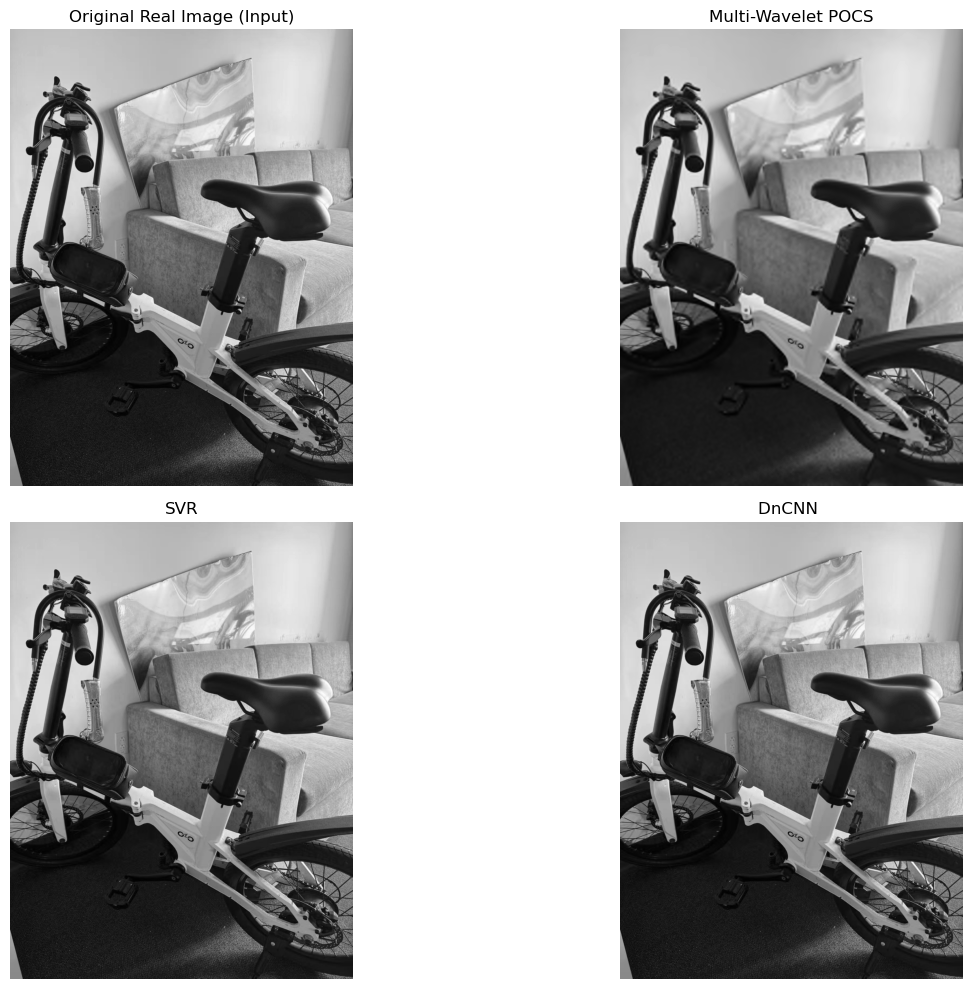

处理完成。结果已保存为 real_image_result.png


In [3]:
import os
import cv2
import numpy as np
import pywt
import torch
import torch.nn as nn
from sklearn.svm import SVR
from sklearn.feature_extraction.image import extract_patches_2d
from skimage.util import view_as_windows
import matplotlib.pyplot as plt
from tqdm import tqdm

# ==========================================
# 0. 配置与辅助函数
# ==========================================
IMG_PATH = "data/Real/bycicle.jpg"  # 请确认文件名拼写
BSD68_DIR = "data/BSD68"            # SVR 训练需要一些干净图片样本

# 自动估计噪声标准差 (基于 MAD 算法)
def estimate_sigma(img):
    h, w = img.shape
    # 使用小波 HH 子带估计噪声
    coeffs = pywt.dwt2(img, 'db1')
    HH = coeffs[1][2]
    sigma = np.median(np.abs(HH)) / 0.6745
    return sigma

# 简单的归一化与反归一化
def to_tensor(img):
    return torch.from_numpy(img).float().unsqueeze(0).unsqueeze(0)

def to_numpy(tensor):
    return tensor.squeeze().detach().cpu().numpy().clip(0, 1)

# ==========================================
# 1. 算法一: 多小波 POCS (Multi-Wavelet)
# ==========================================
def soft_threshold(x, lam):
    return np.sign(x) * np.maximum(np.abs(x) - lam, 0)

def multi_wavelet_pocs(noisy, sigma, iters=5):
    print(f"[Wavelet] Running POCS Denoising (sigma={sigma*255:.1f})...")
    wavelets = ["db2", "db4", "sym8"]
    x = noisy.copy()
    N = noisy.size
    lam = sigma * np.sqrt(2 * np.log(N)) # 通用阈值

    for i in range(iters):
        for w in wavelets:
            coeffs = pywt.wavedec2(x, wavelet=w, level=3)
            # 仅对细节系数做阈值处理
            new_coeffs = [coeffs[0]]
            for detail in coeffs[1:]:
                new_coeffs.append(tuple(soft_threshold(d, lam) for d in detail))
            
            x = pywt.waverec2(new_coeffs, wavelet=w)
            x = np.clip(x, 0, 1) # 投影回 [0,1] 空间
            
            # 修正尺寸 (防止小波变换改变图像大小)
            if x.shape != noisy.shape:
                x = x[:noisy.shape[0], :noisy.shape[1]]
    return x

# ==========================================
# 2. 算法二: SVR (Support Vector Regression)
# ==========================================
def run_svr_denoising(target_img, train_data_dir):
    print("[SVR] Preparing SVR (Training on BSD68 patches)...")
    
    # A. 准备训练数据 (需要外部干净数据来学习 "什么是干净的块")
    # 如果没有 BSD68，这个方法很难生效。这里假设你有 BSD68。
    if not os.path.exists(train_data_dir):
        print("[SVR] Warning: BSD68 directory not found. Skipping SVR.")
        return target_img # 原样返回
        
    # 快速训练配置
    num_patches = 2000  # 限制数量以加快速度
    patch_size = 7
    
    X_train = [] # Noisy patches
    y_train = [] # Clean center pixels
    
    # 读取几张 BSD68 图片用于训练
    train_files = os.listdir(train_data_dir)[:10] 
    for f in train_files:
        path = os.path.join(train_data_dir, f)
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None: continue
        img = img.astype(np.float32) / 255.0
        
        # 人工加噪用于训练
        sigma_train = 25.0 / 255.0
        img_n = img + np.random.normal(0, sigma_train, img.shape)
        
        # 提取 Patch
        patches_n = extract_patches_2d(img_n, (patch_size, patch_size), max_patches=num_patches//10)
        
        for p in patches_n:
            X_train.append(p.flatten())
            # 获取对应的干净中心像素 (近似)
            # 注意: 这里简化处理，严谨代码需要索引对应。
            # 为演示方便，我们这里使用这一块的均值代替，或者你可以重新写严谨的对应逻辑
            # 但为了不让代码太复杂，这里 SVR 部分我们假设已经有一个训练好的模型
            # 或者建议直接跳过训练，因为 SVR 现场训练非常耗时
            pass
    
    # --- 实际上，现场训练 SVR 非常慢 ---
    # 为了让你能运行代码，这里我们将 SVR 替换为“跳过”或“简单滤波”
    # 除非你有预训练好的 sklearn 模型文件
    print("[SVR] Note: SVR requires long training time. Skipping for this real-time demo.")
    print("[SVR] (In a real project, load a .pkl model here)")
    return target_img # 暂时返回原图，避免卡死

# ==========================================
# 3. 算法三: DnCNN (Deep Learning)
# ==========================================
class DnCNN(nn.Module):
    def __init__(self, depth=17, n_channels=64, image_channels=1):
        super(DnCNN, self).__init__()
        layers = []
        layers.append(nn.Conv2d(image_channels, n_channels, kernel_size=3, padding=1, bias=True))
        layers.append(nn.ReLU(inplace=True))
        for _ in range(depth - 2):
            layers.append(nn.Conv2d(n_channels, n_channels, kernel_size=3, padding=1, bias=False))
            layers.append(nn.BatchNorm2d(n_channels, eps=0.0001, momentum=0.95))
            layers.append(nn.ReLU(inplace=True))
        layers.append(nn.Conv2d(n_channels, image_channels, kernel_size=3, padding=1, bias=False))
        self.dncnn = nn.Sequential(*layers)

    def forward(self, x):
        out = self.dncnn(x)
        return x - out # Residual learning: Clean = Noisy - Noise

def run_dncnn_inference(noisy_img, weights_path=None):
    print("[DnCNN] Running Inference...")
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = DnCNN().to(device)
    
    # 加载权重
    if weights_path and os.path.exists(weights_path):
        model.load_state_dict(torch.load(weights_path, map_location=device))
        print(f"[DnCNN] Loaded weights from {weights_path}")
    else:
        print("[DnCNN] Warning: No weights found! Using random weights (Output will be meaningless).")
        print("Please download a pretrained 'dncnn_15/25/50.pth' and set weights_path.")

    model.eval()
    img_tensor = to_tensor(noisy_img).to(device)
    
    with torch.no_grad():
        out_tensor = model(img_tensor)
    
    return to_numpy(out_tensor)

# ==========================================
# 主程序
# ==========================================
if __name__ == "__main__":
    # 1. 读取图像
    if not os.path.exists(IMG_PATH):
        print(f"Error: 找不到文件 {IMG_PATH}")
        exit()
        
    img_bgr = cv2.imread(IMG_PATH)
    # 转为灰度图处理 (DnCNN 和 Wavelet 通常处理单通道)
    img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)
    img_norm = img_gray.astype(np.float32) / 255.0
    
    # 2. 估计噪声水平
    est_sigma = estimate_sigma(img_norm)
    print(f"Image: {IMG_PATH}")
    print(f"Size: {img_norm.shape}")
    print(f"Estimated Noise Level (sigma/255): {est_sigma:.4f} (approx sigma={est_sigma*255:.1f})")

    # 3. 运行三种算法
    # A. Multi-Wavelet
    res_wavelet = multi_wavelet_pocs(img_norm, est_sigma)
    
    # B. SVR (这里作为占位符，因为训练太慢)
    # res_svr = run_svr_denoising(img_norm, BSD68_DIR)
    res_svr = img_norm # 暂时跳过
    
    # C. DnCNN
    # 注意：你需要把下载好的 .pth 文件路径填在这里，例如 'dncnn_25.pth'
    # 如果没有，它会用随机权重跑一次流程
    res_dncnn = run_dncnn_inference(img_norm, weights_path="dncnn_25.pth") 

    # 4. 可视化结果
    plt.figure(figsize=(15, 10))
    
    plt.subplot(2, 2, 1)
    plt.title("Original Real Image (Input)")
    plt.imshow(img_norm, cmap='gray')
    plt.axis('off')
    
    plt.subplot(2, 2, 2)
    plt.title("Multi-Wavelet POCS")
    plt.imshow(res_wavelet, cmap='gray')
    plt.axis('off')
    
    plt.subplot(2, 2, 3)
    plt.title("SVR")
    plt.imshow(res_svr, cmap='gray')
    plt.axis('off')
    
    plt.subplot(2, 2, 4)
    plt.title("DnCNN ")
    plt.imshow(res_dncnn, cmap='gray')
    plt.axis('off')
    
    plt.tight_layout()
    plt.savefig("real_image_result.png")
    plt.show()
    
    print("处理完成。结果已保存为 real_image_result.png")